<a href="https://colab.research.google.com/github/emersonprates/Notebooks/blob/main/TransferenciadeApredizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import cv2

#para deep learning
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense, Dropout, Conv2D, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam

#para validaçao do modelo
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
# montando o ambiente google
from google.colab import drive
drive.mount('/content/drive')

import os
caminho_da_pasta = "/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images"
pasta_imagens = Path(caminho_da_pasta)

Mounted at /content/drive


Depois de importar as bibliotecas necessárias para realizar o projeto, vamos utilizar o glob para listas as imagens que possuem padrao .jpg

In [ ]:
#listando as imagens do diretorio
filepaths = list(pasta_imagens.glob(r'**/*.jpg'))
filepaths

[PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.10.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.103.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.101.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.0.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.102.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.1.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.110.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.113.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/base/cat_dog_images/cachorinho/dog.107.jpg'),
 PosixPath('/content/drive/My Drive/Colab Notebooks/fase 5/b

Tratando os dados

como proximo passo vamos armazenar as targets do nosso modelo e as imagens em uma lista. para todas as imagens localizadas em filepaths, vamos percorrer um loop cada uma das imagens e realizar algumas tratativas como por exemplo redimensionar a imagem e normalizar o intervalo de pixels para ficar entre 0 e 1 e armaze-las nas listas

aqui é importante relembrar que redes neurais funcionam melhor quando estao com os dados normalizados padronizados

In [ ]:
# inicializando rotulos e listas de imagens para armazenas dados
labels = [] #armazenando as variaveis target
images = [] #armazenando imagens

#definindo o tamanho da dimensao da imagem
image_size = 64

#um loop for para definir as variaveis x e y para os modelos
for filepath in filepaths:
  #divide o nome do caminho para extrair o cabeçalho do caminho com split
  head = os.path.split(filepath)
  #divide o cabeçalho do caminho anterior para extrair o nome do animal
  animal = os.path.split(head[0])
  #armazena o nome do animal na lista de labels
  labels.append(animal[1])
  #obtem a imagem do caminho com cv2
  img = cv2.imread(str(filepath))
  #redimensiona a imagem e normalize o intervalo de pixxel para ficar entre 0 er 1 (padronizaçao)
  #utilizando float32 para criar uma precisao limitada (menor demanda de memoria em comparacao)
  img = cv2.resize(img, (image_size, image_size)).astype('float32') / 255.0
  #adiciona a imagem na lista de imagens
  images.append(img)

#converte a imagem em lista de array
images = np.array(images)
#converte as labels para a lista de array
labels = np.array(labels)

agora temos as imagens armazenadas em um formato de um grande array na variavel "imagens" e rotulos em "labels"

In [ ]:
images.shape

(1400, 64, 64, 3)

In [ ]:
images

array([[[[0.22745098, 0.4392157 , 0.5529412 ],
         [0.16078432, 0.37254903, 0.5176471 ],
         [0.21176471, 0.3647059 , 0.46666667],
         ...,
         [0.3764706 , 0.4745098 , 0.5137255 ],
         [0.38039216, 0.4745098 , 0.52156866],
         [0.3764706 , 0.46666667, 0.5294118 ]],

        [[0.12941177, 0.28627452, 0.4117647 ],
         [0.21960784, 0.38431373, 0.49803922],
         [0.34901962, 0.47058824, 0.5294118 ],
         ...,
         [0.3764706 , 0.4745098 , 0.5137255 ],
         [0.38431373, 0.47843137, 0.5254902 ],
         [0.3882353 , 0.47843137, 0.5411765 ]],

        [[0.3254902 , 0.4509804 , 0.5254902 ],
         [0.36078432, 0.47058824, 0.5254902 ],
         [0.42352942, 0.5019608 , 0.5294118 ],
         ...,
         [0.3882353 , 0.4862745 , 0.5254902 ],
         [0.38431373, 0.47843137, 0.5294118 ],
         [0.3647059 , 0.45490196, 0.5176471 ]],

        ...,

        [[0.8352941 , 0.79607844, 0.7254902 ],
         [0.83137256, 0.7921569 , 0.72156864]

In [ ]:
labels

array(['cachorinho', 'cachorinho', 'cachorinho', ..., 'gatinho',
       'gatinho', 'gatinho'], dtype='<U10')

Construindo um dataframe

com as imagens e rotulos ja definidos, vamos contruir um dataframe com o nome do caminho e o rotulo da imagem

In [ ]:
#salvando a lista de caminhos de arquivo
pd_filepaths = pd.Series(filepaths, name='Filepath').astype(str)

In [ ]:
#Visualizando o caminho das imagens
print(pd_filepaths[:3])

0    /content/drive/My Drive/Colab Notebooks/fase 5...
1    /content/drive/My Drive/Colab Notebooks/fase 5...
2    /content/drive/My Drive/Colab Notebooks/fase 5...
Name: Filepath, dtype: object


In [ ]:
# visualizando os rotulos das imagens
print(labels[:3])

['cachorinho' 'cachorinho' 'cachorinho']


In [ ]:
#adicionando a label
pd_labels = pd.Series(labels, name='Label')

In [ ]:
#concatenando the filepaths and labels
df = pd.concat([pd_filepaths, pd_labels], axis=1)

In [ ]:
df.head()

,Filepath,Label
0,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
1,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
2,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
3,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
4,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho


In [ ]:
df.tail()

,Filepath,Label
1395,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho
1396,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho
1397,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho
1398,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho
1399,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho


perceba que nossos dados estao em ordem de classes, isso pode ser um problema para o modelo, entao vamos utilizar o sample para embaralhar o dataframe

In [ ]:
#embaralhando o dataframe
df = df.sample(frac=1).reset_index(drop = True)

In [ ]:
df.head()

,Filepath,Label
0,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
1,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
2,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
3,/content/drive/My Drive/Colab Notebooks/fase 5...,cachorinho
4,/content/drive/My Drive/Colab Notebooks/fase 5...,gatinho


In [ ]:
#cria uma copia do dataframe com apenas uma imagem de cada animal
df_singles = df.copy().drop_duplicates(subset=('Label')).reset_index()

In [ ]:
len(df_singles)

2

In [ ]:
#define o numero de classes
num_classes = df_singles.shape[0]

In [ ]:
num_classes

2

agora temos as classes mapeadas na variavel num_classes, vamos visualizar duas amostras de imagens dentro do dataset

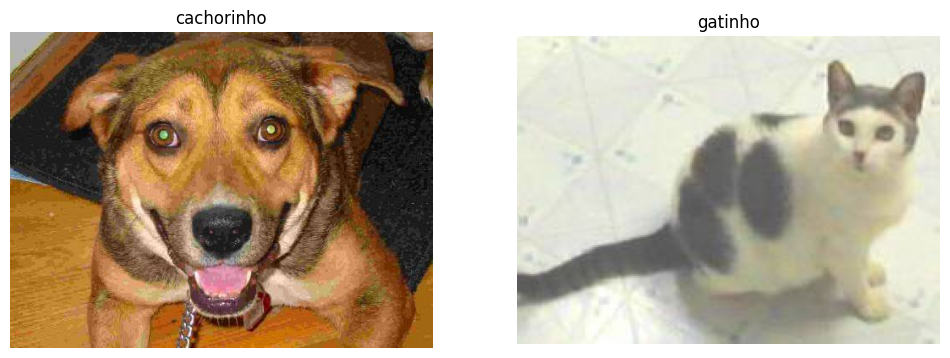

In [ ]:
#configura o numero de linhas e collunas para visulaizar os dados no ploit
row = 1
column = 2

#dimensoes das imagens
plt.figure(figsize=(12,9))
#loop para cada animal
for i in range(num_classes):
  #defina uma variavel de imagem local para i imagem no dataframe de singles
  image = df_singles.Filepath[i]
  #define a posicao da imagem a ser plotada
  plt.subplot(row, column, i+1)
  #mostra a imagem
  plt.imshow(plt.imread(image))
  #adiciona o rotulo do bicho que corresponde a imagem
  plt.title('{}'.format(df_singles.Label[i]))
  #desliga o eixo de plotagem
  plt.axis('off')
  #faça com que o preenchimento ao redor das imagens seja minimo
  plt.tight_layout
plt.show()

Separando em treino e teste a base de dados

agora com as imagens e classes organizadas, podemos aplicar o train_test_split para separar as bases de treinamento e teste

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(images,
                                           labels, test_size=0.2, stratify=labels, random_state=44)

In [ ]:
#analisando a dimensao dos dados
x_train.shape

(1120, 64, 64, 3)

In [ ]:
x_test.shape

(280, 64, 64, 3)

Sabemos que as imagens são basicamente uma matriz de pixels e para colocar as imagens dentro da arquitetura das redes convolucionais, é preciso "achatar" essas matrizes multidimensionais em vetores unidimensionais. Uma das camadas da rede, a Flatten(), é uma das partes da rede que achata os dados antes de entrar nas camadas densas.

In [ ]:
#achatar os dados de teste e treino
x_train_flat = x_train.reshape(x_train.shape[0], x_train.shape[1]* x_train.shape[2]* x_train.shape[3])
x_test_flat = x_test.reshape(x_test.shape[0], x_test.shape[1] * x_test.shape[2] * x_test.shape[3])

In [ ]:
#visualizando a transformacao
x_train_flat.shape

(1120, 12288)

Como próximo passo, vamos converter as classes de texto em binárias. Para esse procedimento, vamos utilizar o método LabelEncoder().

In [ ]:
#converter as strings em numericos
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.fit_transform(y_test)

#converte um vetor de classe (inteiros) em uma matriz de classe categorica
y_train_tf = keras.utils.to_categorical(y_train, num_classes)
y_test_tf = keras.utils.to_categorical(y_test, num_classes)

Vamos configurar agora como próximo passo o ModelCheckpoint para usar os melhores pesos para este modelo. Um dos benefícios do ModelCheckpoint é salvar uma cópia do modelo em disco em intervalos regulares (como após cada época de processamento) para que você possa retomar o treinamento a partir do ponto em que parou, minimizando perdas de tempo e recursos computacionais.

In [ ]:
from distutils.file_util import copy_file

# Defina um objeto ModelCheckpoint para usar os melhores pesos para este modelo
checkpointer = ModelCheckpoint(filepath="weights.best.keras", verbose=0, save_best_only=True) # save best model

Como próximo passo, vamos definir a entrada da rede e armazenar na variável input_shape e em seguida configurar a learning rate e a queda do peso do otimizador com weight_decay.

O argumento weight_decay é usado para aplicar regularização L2 (também conhecida como regularização de peso) às camadas densas (fully connected) de uma rede neural durante o treinamento. A regularização L2 funciona adicionando um termo à função de perda durante o treinamento que penaliza os pesos maiores.

In [ ]:
#Define a forma de entrada das imagens passadas pelo modelo
input_shape = (image_size, image_size, 3)

#Defina a taxa de aprendizado e a queda de peso para o otimizador usar
learning_rate = 0.001

Agora chegou o momento tão esperado, nossa rede neural convolucional! 🦾

Acompanhe comigo o código a seguir e vamos comentando sobre cada passo da construção da rede:

In [ ]:
tf.random.set_seed(44) #definindo uma semente aleatoria para utilizar sempre os mesmos dados durante nossos testes

model = Sequential() #Abrindo a sequencia do modelo

#1 camada convolucional com 128 neuronios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
#padding ativado (sem bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(128,
                 kernel_size=(3,3),
                 strides=(2,2),
                 padding='same',
                 activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001),
                 input_shape=input_shape)),

# camada de maxpolling ativada, com uma matriz 2x2. padding ativado
model.add(MaxPooling2D(pool_size=(2,2), strides=None, padding='same'))

#regularização de dropout ativada
model.add(Dropout(0.5))

# 2 camada convulucional com 92 neuronios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
# padding ativado (sem bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(92,
                 kernel_size=(3,3),
                 strides=(2,2),
                 padding='same',
                 activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001))),

#camada de maxpooling2d ativada, com uma matriz 2x2. padding ativado
model.add(MaxPooling2D(pool_size=(2,2), strides=None, padding='same'))

#regularização de dropout ativada
model.add(Dropout(0.5))

#camada que achata os dados da imagem
model.add(Flatten())
#camada dense da rede neural convolucional + função de ativação relu
model.add(Dense(256, activation='relu'))
#camada de saida da rede, utilizando a função de ativacao softmax para criar a probabilidade de pertencimento das classes
model.add(Dense(y_train_tf.shape[1], activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Agora vamos configurar uma técnica de validação do modelo para evitar que as épocas de processamento não executem o modelo sem ter melhoras significativas, o early stopping. Essa técnica monitora a perda no conjunto de validação e interrompe o treinamento se a perda não diminuir significativamente por um número especificado de épocas (10 no exemplo) após uma pequena melhoria (mínimo delta de 1e-5). Essa é uma técnica útil para evitar o overfitting e economizar tempo de treinamento. (Podemos dizer que essa técnica ajuda o modelo a não ficar "estagnado", ou seja, se encontra em estado estacionário).

Além da configuração do early stopping, vamos configurar a função de custo com o Adam. A função de custo tem o papel de ajustar os pesos de uma rede neural durante o treinamento. o Adam também utiliza um termo de momentum para acelerar o processo de aprendizado. O momentum ajuda o algoritmo a superar regiões planas ou mínimos locais rasos, permitindo que ele "ganhe velocidade" na direção do mínimo global. O otimizador Adam requer menos configuração de hiperparâmetro da taxa de aprendizagem, então um valor padrão n = 0,001 pode ser uma boa opção!

Lembrando que a taxa de aprendizagem (learning rate) é responsável por controlar o tamanho dos “passos” das interações para encontrar um melhor mínimo local (menor erro). Uma taxa de aprendizagem baixa pode ser mais precisa, porém pode demorar para encontrar o mínimo local. Uma taxa de aprendizado alta pode deixar passar o melhor mínimo local.

In [ ]:
# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='auto') #Aqui utilizando early stopping

# Compilando o modelo e aplicação a função de custo Adam (utilizando a learning rate que configuramos anteriormente)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate), metrics=['accuracy'])

# salve os dados do modelo em um arquivo h5
model.save('./cat_dog.h5')
#resumo do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 92)       │       106,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 92)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 92)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       377,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,262 (1.86 MB)

 Trainable params: 487,262 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

Por fim, vamos configurar o número de épocas de processamento em conjunto com a base de validação das épocas. Nesse momento também é importante configurar o número de batchs que o modelo irá processar por épocas para atualizar os pesos. Em outras palavras, as batchs são as quantidades de dados de treinamento que são processadas de uma só vez antes que os pesos do modelo sejam atualizados com base nos gradientes calculados.

In [ ]:
 #treinando o modelo
 history = model.fit(x_train, y_train_tf, validation_split=0.25, callbacks=[monitor,checkpointer],
                     verbose=1,epochs=45,batch_size=50, shuffle=True)

Epoch 1/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step - accuracy: 0.5060 - loss: 0.8087 - val_accuracy: 0.5429 - val_loss: 0.7802
Epoch 2/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.5393 - loss: 0.7701 - val_accuracy: 0.5036 - val_loss: 0.7683
Epoch 3/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.5417 - loss: 0.7545 - val_accuracy: 0.5464 - val_loss: 0.7505
Epoch 4/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.5845 - loss: 0.7437 - val_accuracy: 0.5429 - val_loss: 0.7410
Epoch 5/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 279ms/step - accuracy: 0.6000 - loss: 0.7241 - val_accuracy: 0.6143 - val_loss: 0.7195
Epoch 6/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.6381 - loss: 0.7018 - val_accuracy: 0.5893 - val_loss: 0.7032
Epoch 7/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.6607 - loss: 0.6737 - val_accuracy: 0.6464 - val_loss: 0.6696
Epoch 8/45
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.6714 - loss: 0.6476 - val_accuracy: 0.

#Validação do modelo

Existem duas métricas importantes que devemos analisar após executar a rede neural, o valor de erro observado e o valor de acurácia por épocas de processamento. Uma boa prática é analisarmos com gráficos de linhas para identificarmos as tendências da performance da rede.

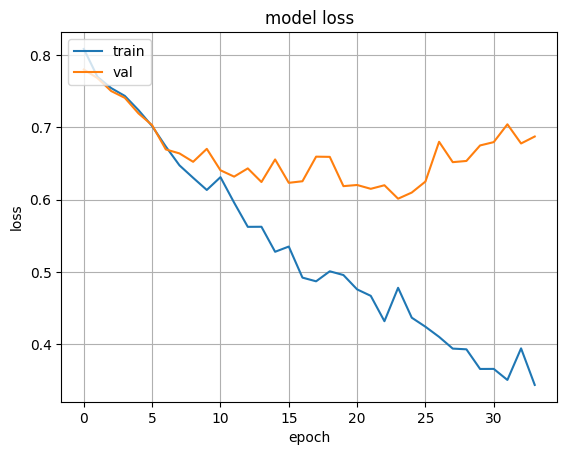

In [ ]:
 #validaçao o erro por epocas
 plt.plot(history.history['loss'])
 plt.plot(history.history['val_loss'])
 plt.title('model loss')
 plt.ylabel('loss')
 plt.xlabel('epoch')
 plt.legend(['train', 'val'], loc='upper left')
 plt.grid(True)
 plt.show()

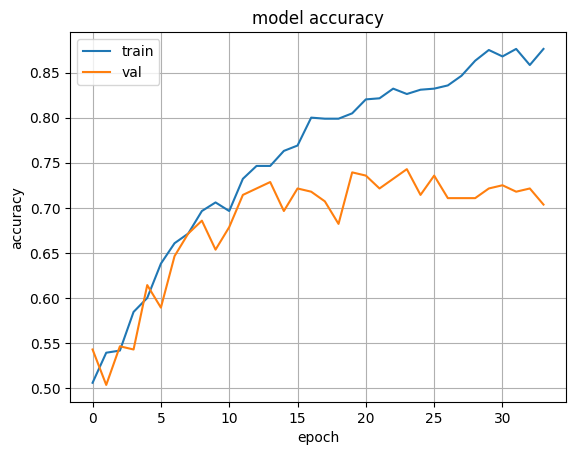

In [ ]:
# validaçao da acuracia por epocas
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

Show! Agora vamos armazenar as predições da base de teste na variável de predição cnn_pred_cat_dog:

In [ ]:
cnn_pred_cat_dog = model.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


Em seguida, vamos utilizar o argmax do numpy para encontrar a classe com a maior probabilidade prevista para cada amostra. (Lembrando que utilizamos a softmax)

In [ ]:
# Define o índice do valor máximo do modelo de previsão para uma variável
# O valor máximo indica o caractere de previsão do modelo que a imagem representa
cnn_pred_cat_dog = np.argmax(cnn_pred_cat_dog, axis=1)

#define uma variavel para armazenar o rotulo que apresenta o resultado veradeiro
y_true = np.argmax(y_test_tf, axis=1)

Agora vamos organizar os nomes dos animais (gatinhos e cachorrinhos) em uma variável, a fim de criar uma lista única de nomes de animais, ordenados alfabeticamente. Vamos também remover duplicatas e ordenar os nomes em ordem alfabética, resultando em uma lista única, limpa e ordenada de nomes de animais.

In [ ]:
#cria um array de nomes e caracteres igual ao array de labels
animal_names = labels
#reduza os nomes dos animais para apenas valores dict unicos
animal_names = list(dict.fromkeys(animal_names))
#Ordena os caracteres em ordem alfabética, qual é a ordem em que os dados são alimentados
animal_names = sorted(animal_names)

Importante analisar o escopo das classes, então vamos utilizar o classification_report e analisar os resultados por escopo das variáveis targets

In [ ]:
#criando a matriz de confusao
cnn_cm_cat_dog = metrics.confusion_matrix(y_true, cnn_pred_cat_dog)
#definindo a acuracia
cnn_accuracy_cat_dog = metrics.accuracy_score(y_true, cnn_pred_cat_dog)

#print do classification report
print(metrics.classification_report(y_true, cnn_pred_cat_dog, target_names=animal_names))
#print da acuracia
print("accuracy score: {}".format(cnn_accuracy_cat_dog))

              precision    recall  f1-score   support

  cachorinho       0.72      0.73      0.73       140
     gatinho       0.73      0.72      0.72       140

    accuracy                           0.72       280
   macro avg       0.73      0.72      0.72       280
weighted avg       0.73      0.72      0.72       280

accuracy score: 0.725


Por fim, vamos criar uma função para adivinhar os animaizinhos?

In [ ]:
#Função para adivinhar o animal
def guess_animal(filepath):
  #converte o caminho do arquivo para uma imagem
  image = cv2.imread(filepath)
  #redimensione a imagem e normalize o intervalo de pixels para ficar entre 0 e 1
  img = cv2.resize(image, (image_size, image_size)).astype('float32') / 255.0
  #expandir a forma do array de imagens
  img = np.expand_dims(img, axis=0)
  #usando o modelo para prever o animal que representa a imagem
  pred=model.predict(img)
  #definindo uma variavel para armazenar o indice que representa o caractere que representa a imagem
  classes=np.argmax(pred,axis=1)
  #print no nome do animal previsto
  print(animal_names[classes[0]])
  #plote a imagem do animal
  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  #desliga o eixo de plotagem
  plt.axis('off')

#Testando o modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
gatinho


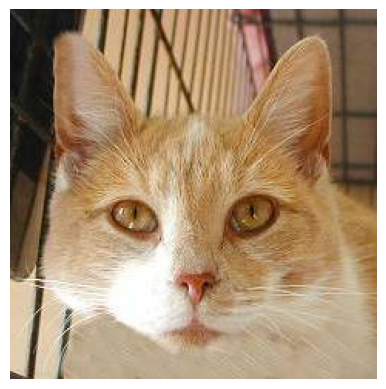

In [ ]:
guess_animal('/content/drive/My Drive/Colab Notebooks/fase 5/base/Teste imagens cães e gatos/cat.202.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
gatinho


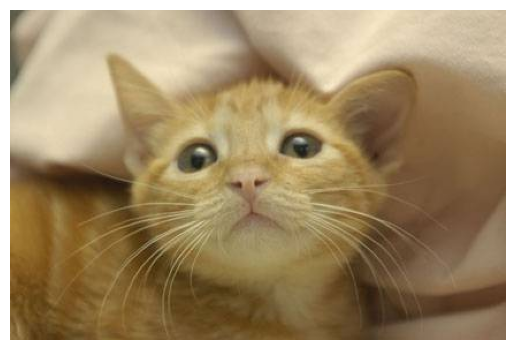

In [ ]:
guess_animal('/content/drive/My Drive/Colab Notebooks/fase 5/base/Teste imagens cães e gatos/cat.475.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
cachorinho


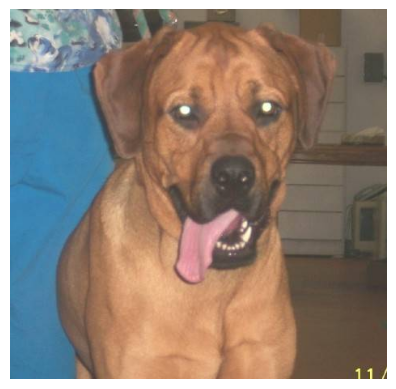

In [ ]:
guess_animal('/content/drive/My Drive/Colab Notebooks/fase 5/base/Teste imagens cães e gatos/dog.30.jpg')

#Criando uma rede neural transfer learning com MobileNetV2 📚
Problema identificado nas redes neurais CNN construídas do zero:

Perceba aqui que a nossa rede rede neural CNN para classificar cães e gatos não foi tão eficaz assim. Dentro de um dos problemas de deep learning, temos a questão de overfitting que pode ser ocasionada por vários cenários.

Perceba que ao analisar o gráfico da nossa rede neural convolucional, até a 10ª época de processamento, os conjuntos de treinamento e validação pareciam andar juntos em questão de performance, mas esse comportamento foi se perdendo ao longo do processamento da rede, nos resultado em 71% de acurácia para validação e 84% para treinamento.


(grafico celula 36 ['model accuracy'])


Existem muitas formas de reduzir o overfitting em deep learning, tal como técnicas de regularização, batch normalization e também aumentar o tamanho da base de treinamento dos dados. Parece muito, mas 1000 imagens podem ser muito pouco para ensinar uma rede neural a aprender os detalhes e particularidades de características de imagens. Se utilizarmos por exemplo uma rede neural que já foi treinada com milhares de imagens de amostra, com certeza seu desempenho pode melhorar muito. Dentro do treinamento de redes neurais convolucionais, no início da extração de características de imagens, alguns passos podem se tornar “padrão” em qualquer tipo de imagem, tal como identificação de bordas por exemplo. As camadas iniciais e centrais são aplicadas à aprendizagem por transferência, e as últimas camadas são apenas recicladas. A rede faz uso dos dados rotulados da tarefa na qual foi treinado.Se tivermos uma rede neural transfer learning que já sabe identificar e muito bem esse tipo de comportamento, podemos ganhar performance e dar um upgrade no nosso modelo e conseguir classificar outros tipos de imagens dado o aprendizado obtido.

Solução prospota:

Para dar um upgrade em nossa rede neural, vamos criar uma rede transfer learning utilizando a biblioteca do Keras, a MobileNetV2!

MobileNetV2 é uma arquitetura de rede neural convolucional eficiente que utiliza blocos de gargalo, convoluções separáveis, camadas residuais e outras técnicas para equilibrar o desempenho e a eficiência de recursos.

Vamos analisar se a transfer learning classifica esse cachorrinho com sono de forma correta?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
gatinho


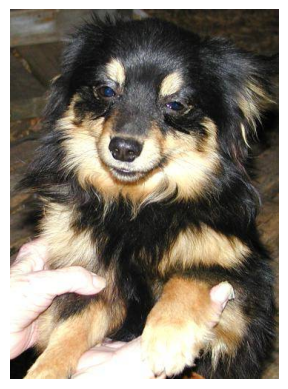

In [ ]:
guess_animal('/content/drive/My Drive/Colab Notebooks/fase 5/base/Teste imagens cães e gatos/dog.238.jpg')

Veja que a nossa CNN feita a mão, entendeu que esse cachorrinho é um gatinho. E isso de deve por conta dos olhinhos de cachorro estar fechados, lembrando assim os de um gato, né?

Vamos para o desafio!

Vamos codar nossa rede?

Vamos iniciar importando as bibliotecas necessárias do keras para criar a transfer learning e em seguida já começar a construção do modelo. Vamos chamar a classe MobileNetV2 e configurar dois hiperparâmetros muito importantes: weights e include_top.

weights são os pesos da rede que foram treinados pela MobileNetV2.
include_top exclui a camada final de classificação da rede, ou seja, ela utiliza todo o treinamento aprendido pela MobileNetV2 no conjunto de imagens da ImageNet, mas na hora de criar os rótulos, conseguimos criar de forma personalizada de acordo com a nossa rede neural tratada no assunto desejado.
E porque essa rede "pré-treinada" funciona?

Bem, porque alguns passos comuns aprendidos em redes neurais como por exemplo:

  - Convoluções de Bordas e Texturas
  - Características Complexas de Objetos
  - Hierarquia de Características
  - Representações de Alto Nível
  - Redução da Dimensionalidade
  
Uma das principais características da MobileNetV2 é sua capacidade de generalização. Como foi treinada em um conjunto de dados diversificado e desafiador, ela pode reconhecer uma ampla variedade de objetos e padrões em imagens de entrada.

In [ ]:
#deep learning
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Carregue o modelo MobileNetV2 pré-treinado (sem as camadas densas no topo)
# O MobileNetV2 é uma rede neural pré-treinada que foi treinada em um grande conjunto de dados chamado ImageNet, que contém milhões de imagens de várias categorias diferentes.
# weights='imagenet': carregar os pesos pré-treinados da versão do MobileNetV2 que foi treinada no conjunto de dados ImageNet
# include_top=False: excluindo a camada de classificação final (top) da rede. Essa camada de classificação normalmente consiste em uma camada densa (fully connected)
# que produz saídas para cada classe no conjunto de dados original do ImageNet. Excluindo essa camada, você está preparando o modelo para personalizar a camada de classificação para uma nova tarefa.

base_model = MobileNetV2(weights='imagenet', include_top=False)

#adicione camadas personalizadas no topo para a classificaçao de caes e gatos
x = base_model.output
x = GlobalAveragePooling2D()(x) # reduzir a dimensionalidade dos dados espaciais antes da camada de saída,
x = Dense(128, activation='relu')(x) #funcao de ativação relu
predictions = Dense(2, activation='softmax')(x) # duas saídas (duas classes, cachorrinhos e gatinhos)

#modelo final
model = Model(inputs=base_model.input, outputs=predictions)

/tmp/ipykernel_10982/1206109931.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Próximo passo agora é configurar o layer.trainable.

Esse parametro é importante para manter as camadas já treinadas pela MobileNet congelada. Aqui todas as camadas do modelo MobileNet pré-treinado são congeladas, e em seguida, camadas personalizadas são adicionadas para realizar a identificação de cães e gatos. Durante o treinamento, apenas as camadas personalizadas terão seus pesos ajustados, enquanto as camadas pré-treinadas permanecerão inalteradas. Para esse efeito acontecer, devemos configurar esse parâmetro como "False".

In [ ]:
#congelar todas as camadas pre treinadas

for layer in base_model.layers:
  layer.treinable = False

E chegou o momento de compilar o modelo!

Aqui vamos utilizar a função de custo adam, otimizando assim a identificação do menor erro possível do modelo (loss function).

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Agora como próximo passo, vamos pegar nossas imagens de cães e gatos e "tunar" elas com ImageDataGenerator! Essa ferramenta é muito poderosa para aumentar os dados e pré-processar as imagens. Ele permite que você crie um fluxo de dados de imagens que pode ser usado para treinar modelos de aprendizado profundo.